In [ ]:
#===============================
# Step 1: Load the package 
#===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
print("Libraries imported")

Libraries imported


In [17]:
#===============================
# Step 2: Load the raw data 
#===============================
print("Dataset loading ...")
df = pd.read_csv("../data/raw/loan_data.csv")
print("Dataset loaded successfully !")
print("shape of dataset",df.shape)
print(df.head())

Dataset loading ...
Dataset loaded successfully !
shape of dataset (1000, 12)
   gender married dependents     education self_employed  applicant_income  \
0    Male     Yes          2  Not Graduate            No            6898.0   
1    Male     Yes          0      Graduate            No           11532.0   
2  Female     Yes         3+      Graduate            No            2705.0   
3    Male     Yes          1      Graduate            No           13671.0   
4    Male     Yes          0      Graduate            No            8459.0   

   coapplicant_income  loan_amount  loan_term  credit_history property_area  \
0               450.0        498.0      480.0             1.0         Urban   
1              3009.0        301.0      120.0             1.0     Semiurban   
2              3419.0         67.0      480.0             1.0         Rural   
3              4394.0        453.0      360.0             NaN         Urban   
4              3433.0        477.0      360.0             

In [18]:
#=========================================================
# Step 3: Understanding structure - schema, datatype, null 
#=========================================================
print("Get the data information")
print(df.info())


Get the data information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              1000 non-null   object 
 1   married             1000 non-null   object 
 2   dependents          1000 non-null   object 
 3   education           1000 non-null   object 
 4   self_employed       1000 non-null   object 
 5   applicant_income    1000 non-null   float64
 6   coapplicant_income  983 non-null    float64
 7   loan_amount         969 non-null    float64
 8   loan_term           1000 non-null   float64
 9   credit_history      912 non-null    float64
 10  property_area       1000 non-null   object 
 11  loan_status         1000 non-null   object 
dtypes: float64(5), object(7)
memory usage: 93.9+ KB
None


In [19]:
print("---------------------------------------")
print("\n Find any missing value")
print(df.isnull().sum())

---------------------------------------

 Find any missing value
gender                 0
married                0
dependents             0
education              0
self_employed          0
applicant_income       0
coapplicant_income    17
loan_amount           31
loan_term              0
credit_history        88
property_area          0
loan_status            0
dtype: int64


In [ ]:
#=========================================================
# Step 4: drop the duplicate value
#=========================================================
before = len(df)
df = df.drop_duplicates()
print(f"[preprocess] Dropped {before - len(df)} duplicate rows.")

[preprocess] Dropped 0 duplicate rows.


In [ ]:
#=========================================================
# Step 5: fill the null value with median 
#=========================================================
median = df['coapplicant_income'].median()
df['coapplicant_income']=df['coapplicant_income'].fillna(median)
df['loan_amount']=df['loan_amount'].fillna(df['loan_amount'].median())
df['credit_history'] =df['credit_history'].fillna(df['credit_history'].median())

In [ ]:
#=========================================================
# Step 6: standerdize column names (basic cleanup) 
#=========================================================
print("Clean column name (lowercase, underscores) .........")
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")
print("column names standardized :")
print(df.columns.to_list())

Clean column name (lowercase, underscores) .........
column names standardized :
['gender', 'married', 'dependents', 'education', 'self_employed', 'applicant_income', 'coapplicant_income', 'loan_amount', 'loan_term', 'credit_history', 'property_area', 'loan_status']


In [28]:
#=========================================================
# Step 7: Basic status check (spot outlier or issues)
#=========================================================

print("Basic Summary stats for numeric columns :")
print(df.describe())

Basic Summary stats for numeric columns :
       applicant_income  coapplicant_income  loan_amount    loan_term  \
count       1000.000000         1000.000000  1000.000000  1000.000000   
mean        8206.916000         3042.891000   278.675000   276.780000   
std         3905.184552         1721.574388   128.483319   116.977414   
min         1512.000000            8.000000    50.000000   120.000000   
25%         4923.000000         1600.250000   168.750000   180.000000   
50%         8117.000000         3070.000000   284.000000   240.000000   
75%        11541.750000         4448.750000   388.250000   360.000000   
max        14999.000000         5994.000000   498.000000   480.000000   

       credit_history  
count     1000.000000  
mean         0.866000  
std          0.340823  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [29]:
#=========================================================
# Step 8: Find co-relation between dataset
#=========================================================

df.corr(numeric_only=True)

,applicant_income,coapplicant_income,loan_amount,loan_term,credit_history
applicant_income,1.000000,-0.010169,-0.001601,-0.021838,0.024929
coapplicant_income,-0.010169,1.000000,-0.016431,0.004692,-0.005723
loan_amount,-0.001601,-0.016431,1.000000,0.015226,-0.046165
loan_term,-0.021838,0.004692,0.015226,1.000000,0.027330
credit_history,0.024929,-0.005723,-0.046165,0.027330,1.000000


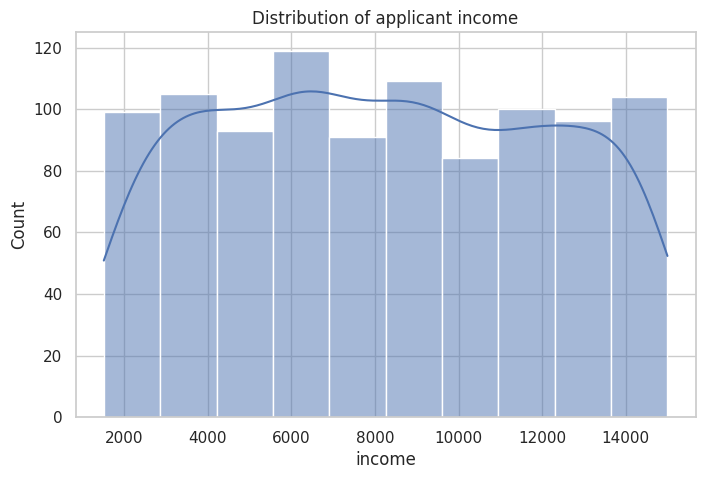

In [32]:
#=========================================================
# Step 8: check visual for distribution
#=========================================================
plt.figure(figsize=(8, 5))
sns.histplot(df["applicant_income"], kde=True, bins=10)
plt.title("Distribution of applicant income")
plt.xlabel("income")
plt.ylabel("Count")
plt.show()

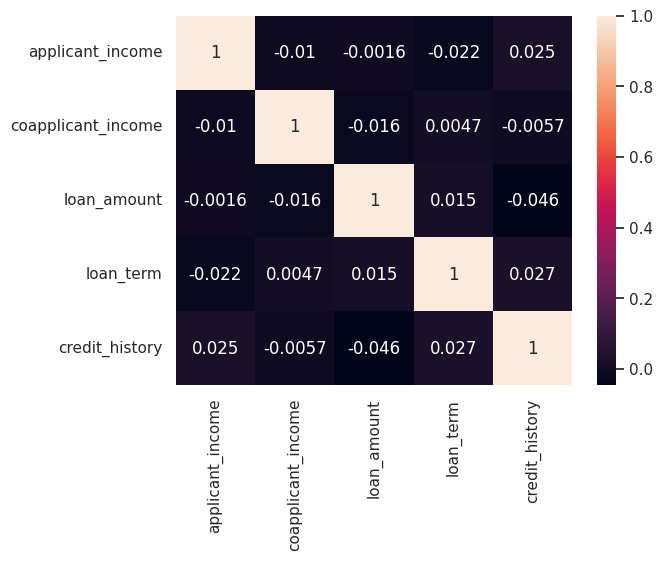

In [34]:
#=========================================================
# Step 8: check visual co-relation
#=========================================================
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              1000 non-null   object 
 1   married             1000 non-null   object 
 2   dependents          1000 non-null   object 
 3   education           1000 non-null   object 
 4   self_employed       1000 non-null   object 
 5   applicant_income    1000 non-null   float64
 6   coapplicant_income  1000 non-null   float64
 7   loan_amount         1000 non-null   float64
 8   loan_term           1000 non-null   float64
 9   credit_history      1000 non-null   float64
 10  property_area       1000 non-null   object 
 11  loan_status         1000 non-null   object 
dtypes: float64(5), object(7)
memory usage: 93.9+ KB


In [36]:
#=========================================================
# Step 8: check for obvious data issues
#=========================================================
print("Looking for nagative or unrealistic value")

for col in ['applicant_income','coapplicant_income','loan_amount','loan_term','credit_history']:
    invalid =df[df[col]<0]
    if not invalid.empty:
        print(f" Found nagative value in {col}: \n{invalid}")
    else:
        print(f"No nagative value found in {col}")

Looking for nagative or unrealistic value
No nagative value found in applicant_income
No nagative value found in coapplicant_income
No nagative value found in loan_amount
No nagative value found in loan_term
No nagative value found in credit_history
